# Temporal Occupancy and Richness Trends (Effort-Corrected)

This notebook avoids raw-count bias from increasing observer effort.
It uses effort-standardized metrics:
- Rarefied annual richness (same number of sampled cells each year)
- District richness per 100 sampled cells
- Species occupancy rate on a stable panel of repeatedly sampled cells

In [19]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', context='paper')
RANDOM_SEED = 42


In [20]:
p = next((x for x in [Path('file6.csv'), Path('../file6.csv'), Path('../../file6.csv')] if x.exists()), None)
if p is None:
    raise FileNotFoundError('file6.csv not found')
cols = ['stateProvince','verbatimScientificName','decimalLatitude','decimalLongitude','eventDate']
df = pd.read_csv(p, usecols=cols, low_memory=False).dropna(subset=cols)
df['eventDate'] = pd.to_datetime(df['eventDate'], errors='coerce')
df['year'] = df['eventDate'].dt.year
for c in ['decimalLatitude','decimalLongitude']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df = df.dropna(subset=['decimalLatitude','decimalLongitude','year'])


In [21]:
lon0 = float(df['decimalLongitude'].median())
lat0 = float(df['decimalLatitude'].median())
lat_rad = np.radians(df['decimalLatitude'].to_numpy())
df['x_km'] = (df['decimalLongitude'].to_numpy() - lon0) * 111.320 * np.cos(lat_rad)
df['y_km'] = (df['decimalLatitude'].to_numpy() - lat0) * 110.574
df['grid_x'] = np.floor(df['x_km'] / 5.0).astype(int)
df['grid_y'] = np.floor(df['y_km'] / 5.0).astype(int)
df['cell_id'] = df['stateProvince'].astype(str) + '|' + df['grid_x'].astype(str) + '_' + df['grid_y'].astype(str)
df['_key'] = df['cell_id'] + '|' + df['verbatimScientificName'] + '|' + df['year'].astype(int).astype(str)
rng = np.random.default_rng(RANDOM_SEED)
df['_r'] = rng.random(len(df))
df_thin = df.sort_values('_r').groupby('_key', as_index=False).head(1)


,year,n_cells,richness,richness_per_100_cells,rarefied_richness_median,rarefied_richness_q05,rarefied_richness_q95
0,2014,205,323,157.560976,323.0,323.00,323.00
1,2015,282,328,116.312057,320.0,314.00,325.00
2,2016,335,335,100.000000,324.0,315.00,331.00
3,2017,359,348,96.935933,331.0,318.00,341.00
4,2018,443,348,78.555305,329.0,318.95,337.00
5,2019,527,352,66.793169,330.0,318.00,339.00
6,2020,546,361,66.117216,330.0,320.00,340.05
7,2021,714,368,51.540616,331.0,315.95,346.00
8,2022,816,358,43.872549,324.0,311.95,338.00
9,2023,955,355,37.172775,317.0,305.00,329.00


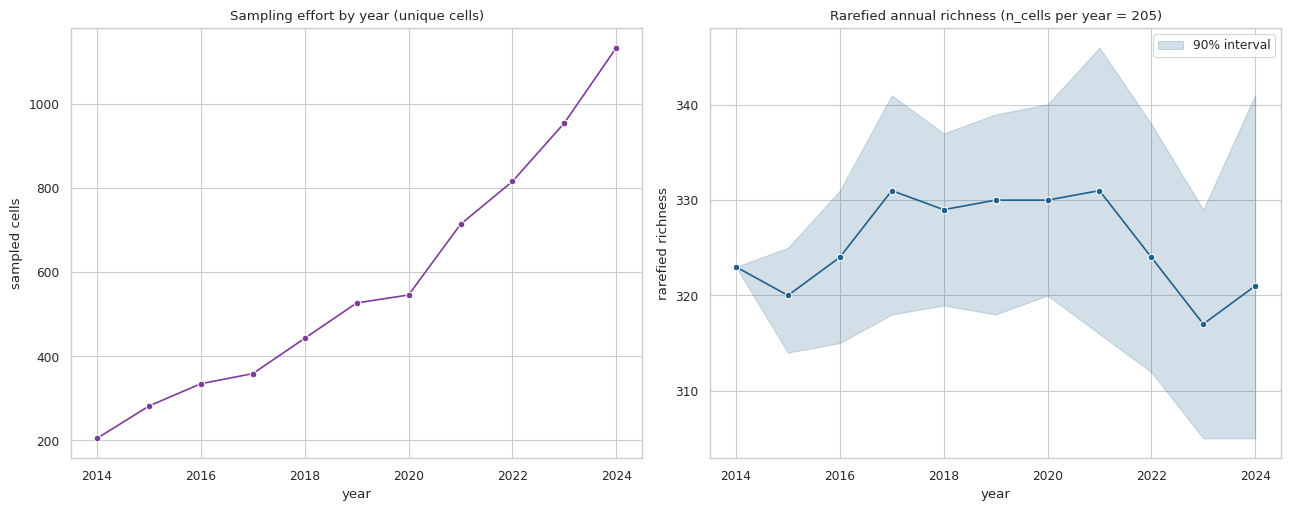

In [22]:
year_total = df_thin.groupby('year', as_index=False).agg(
    n_cells=('cell_id', 'nunique'),
    richness=('verbatimScientificName', 'nunique')
)
year_total['richness_per_100_cells'] = 100 * year_total['richness'] / year_total['n_cells']

# Rarefy each year to the same number of sampled cells to reduce effort bias.
cell_species = (
    df_thin.groupby(['year', 'cell_id'])['verbatimScientificName']
    .apply(lambda s: set(s.astype(str)))
    .reset_index(name='species_set')
)

n_min = int(cell_species.groupby('year')['cell_id'].nunique().min())
boot_n = 300
rng = np.random.default_rng(RANDOM_SEED)
rows = []
for y, g in cell_species.groupby('year'):
    sets = g['species_set'].to_list()
    if len(sets) < n_min or n_min == 0:
        continue
    vals = []
    for _ in range(boot_n):
        idx = rng.choice(len(sets), size=n_min, replace=False)
        sp_union = set()
        for i in idx:
            sp_union |= sets[i]
        vals.append(len(sp_union))
    rows.append({
        'year': y,
        'rarefied_richness_median': float(np.median(vals)),
        'rarefied_richness_q05': float(np.quantile(vals, 0.05)),
        'rarefied_richness_q95': float(np.quantile(vals, 0.95)),
    })

rarefied_year = pd.DataFrame(rows).sort_values('year')
year_compare = year_total.merge(rarefied_year, on='year', how='left').sort_values('year')

display(year_compare.tail(15))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

sns.lineplot(data=year_compare, x='year', y='n_cells', marker='o', color='#7d3c98', ax=axes[0])
axes[0].set_title('Sampling effort by year (unique cells)')
axes[0].set_ylabel('sampled cells')

sns.lineplot(data=year_compare, x='year', y='rarefied_richness_median', marker='o', color='#1f618d', ax=axes[1])
axes[1].fill_between(
    year_compare['year'],
    year_compare['rarefied_richness_q05'],
    year_compare['rarefied_richness_q95'],
    color='#1f618d', alpha=0.2, label='90% interval'
)
axes[1].set_title(f'Rarefied annual richness (n_cells per year = {n_min})')
axes[1].set_ylabel('rarefied richness')
axes[1].legend()

plt.tight_layout()
plt.show()


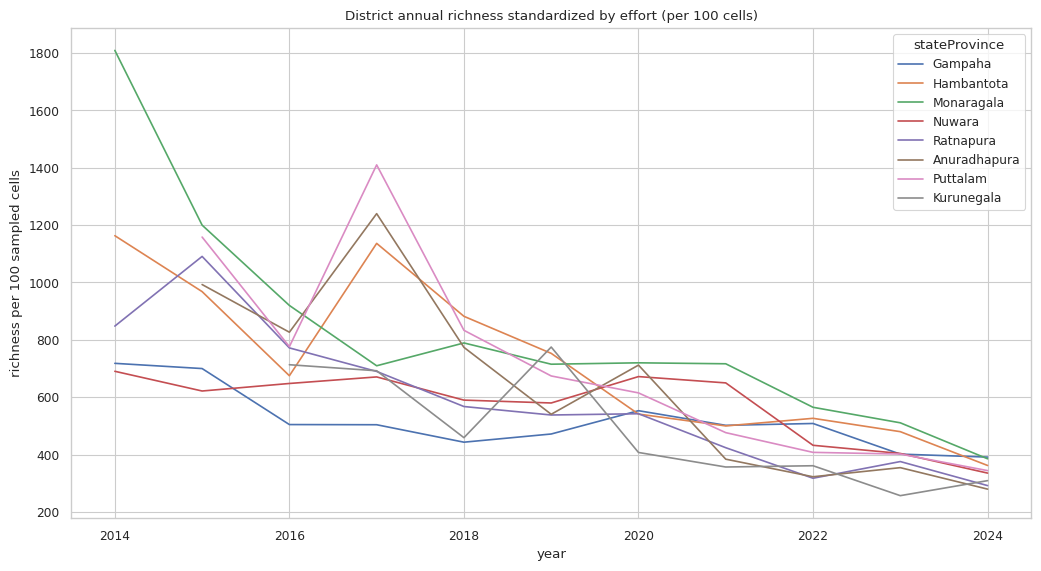

In [23]:
year_district = df_thin.groupby(['year', 'stateProvince'], as_index=False).agg(
    n_cells=('cell_id', 'nunique'),
    richness=('verbatimScientificName', 'nunique')
)
year_district['richness_per_100_cells'] = 100 * year_district['richness'] / year_district['n_cells']

top_d = year_district.groupby('stateProvince')['n_cells'].sum().nlargest(8).index
plot_df = year_district[(year_district['stateProvince'].isin(top_d)) & (year_district['n_cells'] >= 10)]

plt.figure(figsize=(10.5, 5.8))
sns.lineplot(
    data=plot_df,
    x='year',
    y='richness_per_100_cells',
    hue='stateProvince'
)
plt.title('District annual richness standardized by effort (per 100 cells)')
plt.ylabel('richness per 100 sampled cells')
plt.tight_layout()
plt.show()


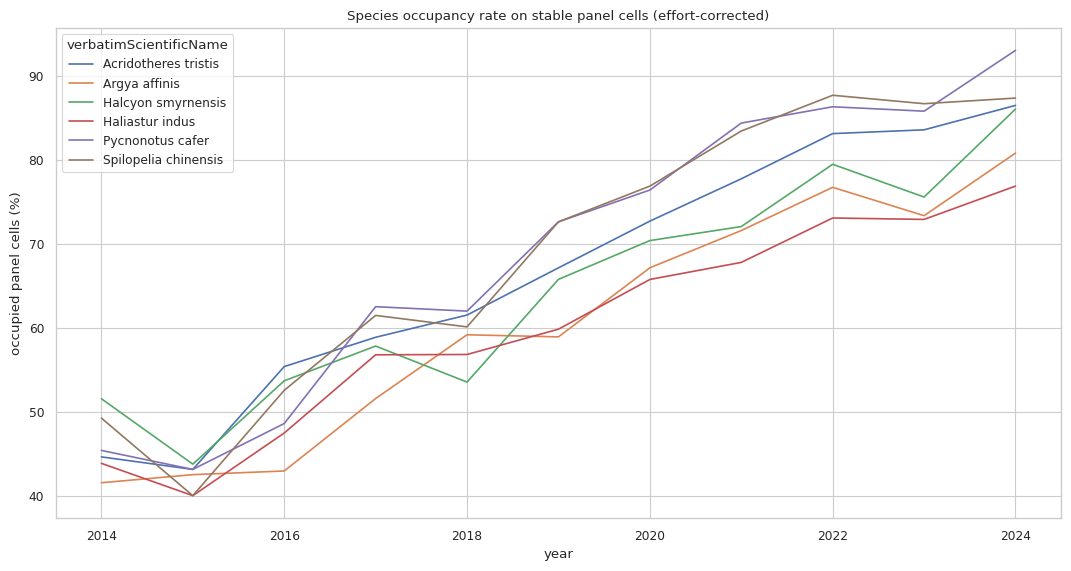

Panel cells used: 229 (observed in >= 8 years)


In [24]:
n_years = int(df_thin['year'].nunique())
panel_threshold = max(2, int(np.ceil(0.7 * n_years)))
cell_years = df_thin.groupby('cell_id')['year'].nunique().rename('n_years_seen').reset_index()
panel_cells = set(cell_years.loc[cell_years['n_years_seen'] >= panel_threshold, 'cell_id'])

panel_df = df_thin[df_thin['cell_id'].isin(panel_cells)].copy()
panel_year_cells = panel_df.groupby('year')['cell_id'].nunique().rename('panel_sampled_cells').reset_index()

species_year_panel = (
    panel_df.groupby(['year', 'verbatimScientificName'])['cell_id']
    .nunique()
    .rename('occupied_panel_cells')
    .reset_index()
    .merge(panel_year_cells, on='year', how='left')
)
species_year_panel['occupancy_rate_pct'] = 100 * species_year_panel['occupied_panel_cells'] / species_year_panel['panel_sampled_cells']

eligible = species_year_panel.groupby('verbatimScientificName')['year'].nunique()
eligible = eligible[eligible >= max(4, int(np.ceil(0.6 * n_years)))].index
plot_species = species_year_panel[species_year_panel['verbatimScientificName'].isin(eligible)]

top_sp = (
    plot_species.groupby('verbatimScientificName')['occupancy_rate_pct']
    .mean()
    .nlargest(6)
    .index
)

plt.figure(figsize=(10.8, 5.8))
sns.lineplot(
    data=plot_species[plot_species['verbatimScientificName'].isin(top_sp)],
    x='year',
    y='occupancy_rate_pct',
    hue='verbatimScientificName'
)
plt.title('Species occupancy rate on stable panel cells (effort-corrected)')
plt.ylabel('occupied panel cells (%)')
plt.tight_layout()
plt.show()

print(f'Panel cells used: {len(panel_cells)} (observed in >= {panel_threshold} years)')
